<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/notebook/4-0_logit_softmax.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

#### 오즈 (Odds)

**오즈**는 어떤 사건이 **일어나지 않을 확률** 대비 **일어날 확률**의 **비율**입니다. "실패 대비 성공이 몇 배 더 가능성 있는가?"를 나타냅니다.

* **공식:**
$$
\text{Odds} = \frac{P(\text{성공})}{P(\text{실패})} = \frac{P(y=1)}{1 - P(y=1)}
$$

* **예시:** 한 팀의 승리 확률이 75%($P=0.75$)라면, 패배 확률은 25%($1-P=0.25$)입니다.
$$
\text{Odds} = \frac{0.75}{0.25} = 3
$$
이것은 "패배할 확률보다 승리할 확률이 **3배 높다**"는 의미입니다.

* **값의 범위:**
    * 확률 (Probability): $$[0, 1]$$
    * 오즈 (Odds): $$[0, \infty)$$

#### 로짓 (Logit)

**로짓**은 **오즈(Odds)에 자연로그(log)를 취한 값**입니다. **Log-odds**라고도 불립니다.

이 변환의 주된 목적은 오즈의 범위($$[0, \infty)$$)를 전체 실수 범위($$(-\infty, \infty)$$)로 확장하여 선형 모델에 적합하게 만들기 위함입니다.

* **공식:**
    $$
    \text{Logit}(P) = \log(\text{Odds}) = \log\left(\frac{P}{1 - P}\right) = z
    $$

* **관계:**
    * 확률이 **0.5**이면, 오즈는 **1**이고, 로짓은 **0**이 됩니다.
    * 확률이 **0.5보다 크면**, 오즈는 **1보다 크고**, 로짓은 **0보다 큽니다**.
    * 확률이 **0.5보다 작으면**, 오즈는 **1보다 작고**, 로짓은 **0보다 작습니다**.

#### 역변환: 시그모이드 함수 (Sigmoid Function)

**시그모이드(Sigmoid) 함수**는 로짓 변환의 역변환입니다. 선형 모델의 예측 결과인 **로짓 값($$z$$)**을 다시 **0과 1 사이의 확률 값**으로 되돌려주는 역할을 합니다.

어떤 실수 값이든 입력받아 S자 형태의 곡선을 그리며 0과 1 사이의 값으로 출력합니다.

* **공식 (로짓 $$z$$로부터 확률 $$P$$ 구하기):**
    $$
    P(y=1) = \frac{1}{1 + e^{-z}}
    $$
    ($$z$$는 선형 회귀식 $$W \cdot X + b$$의 결과값에 해당합니다.)


### 요약

| 변환 단계      | 설명                               | 값의 범위              |
| :------------- | :--------------------------------- | :--------------------- |
| **확률 (P)** | 사건이 일어날 가능성               | $$[0, 1]$$             |
| **오즈 (Odds)** | 실패 대비 성공의 비율              | $$[0, \infty)$$        |
| **로짓 (Logit)** | 오즈에 로그를 취한 값 (선형화)     | $$(-\infty, \infty)$$    |
| **시그모이드** | 로짓을 다시 확률로 변환 (역변환) | $$[0, 1]$$


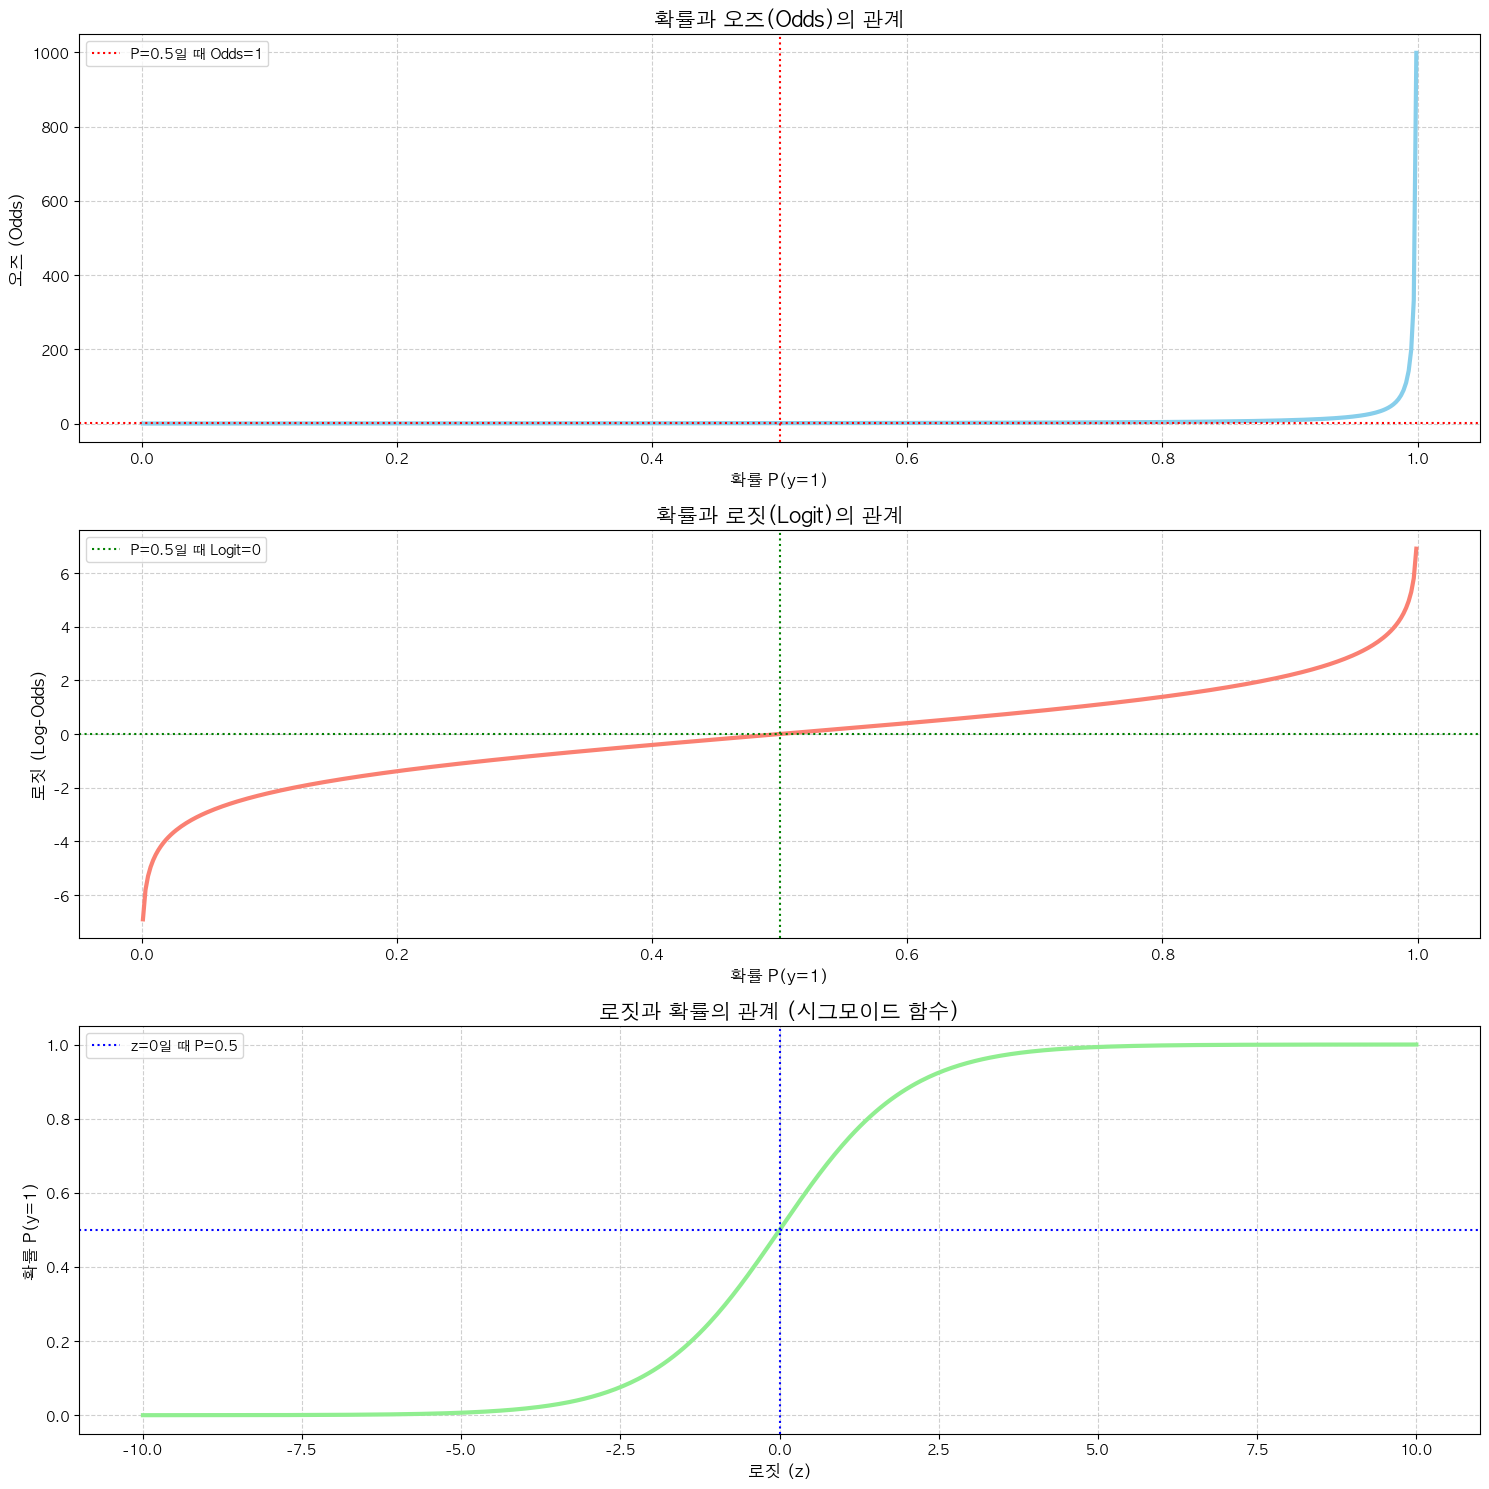

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 생성
# 확률 P(y=1)의 범위 (0과 1에 너무 가까우면 log(0) 또는 1/0 오류가 발생하므로 약간의 여유를 줌)
p = np.linspace(0.001, 0.999, 500)

# Logit(z) 값의 범위
z = np.linspace(-10, 10, 500)


# 2. 계산
# (1) 확률 -> 오즈
odds = p / (1 - p)

# (2) 확률 -> 로짓
logit = np.log(odds)

# (3) 로짓 -> 확률 (시그모이드 함수)
sigmoid_p = 1 / (1 + np.exp(-z))


# 3. 시각화
plt.figure(figsize=(15, 15)) # 전체 그래프 크기 설정

# 그래프 1: 확률 vs 오즈
plt.subplot(3, 1, 1)
plt.plot(p, odds, color='skyblue', lw=3)
plt.title('확률과 오즈(Odds)의 관계', fontsize=15)
plt.xlabel('확률 P(y=1)', fontsize=12)
plt.ylabel('오즈 (Odds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# P=0.5일 때 Odds=1임을 표시
plt.axvline(x=0.5, color='red', linestyle=':', label='P=0.5일 때 Odds=1')
plt.axhline(y=1.0, color='red', linestyle=':')
plt.legend()


# 그래프 2: 확률 vs 로짓
plt.subplot(3, 1, 2)
plt.plot(p, logit, color='salmon', lw=3)
plt.title('확률과 로짓(Logit)의 관계', fontsize=15)
plt.xlabel('확률 P(y=1)', fontsize=12)
plt.ylabel('로짓 (Log-Odds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# P=0.5일 때 Logit=0임을 표시
plt.axvline(x=0.5, color='green', linestyle=':', label='P=0.5일 때 Logit=0')
plt.axhline(y=0, color='green', linestyle=':')
plt.legend()


# 그래프 3: 로짓 vs 확률 (시그모이드 함수)
plt.subplot(3, 1, 3)
plt.plot(z, sigmoid_p, color='lightgreen', lw=3)
plt.title('로짓과 확률의 관계 (시그모이드 함수)', fontsize=15)
plt.xlabel('로짓 (z)', fontsize=12)
plt.ylabel('확률 P(y=1)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# z=0일 때 P=0.5임을 표시
plt.axvline(x=0, color='blue', linestyle=':', label='z=0일 때 P=0.5')
plt.axhline(y=0.5, color='blue', linestyle=':')
plt.legend()


plt.tight_layout() # 그래프 간 간격 자동 조절
plt.show()

네, 3개 클래스에 대한 **소프트맥스(Softmax)** 함수의 동작 방식을 예시와 함께 시각화해 드릴게요.

소프트맥스 함수는 다중 클래스 분류 문제에서 모델의 최종 출력값(로짓 또는 점수)을 각 클래스에 속할 **확률**로 변환하는 역할을 합니다. 각 출력 확률은 0과 1 사이의 값을 가지며, 모든 클래스에 대한 확률의 총합은 항상 1이 됩니다.

## 소프트맥스 함수 🧠

어떤 모델이 3개의 클래스(예: '개', '고양이', '새')에 대해 각각의 점수(로짓) $$z_1, z_2, z_3$$를 출력했다고 가정해 봅시다. 각 클래스 $$i$$에 대한 소프트맥스 확률 $$P(y=i)$$는 다음 수식으로 계산됩니다.

$$
P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{3} e^{z_j}} = \frac{e^{z_i}}{e^{z_1} + e^{z_2} + e^{z_3}}
$$

이 과정을 통해 가장 높은 점수를 가진 클래스가 가장 높은 확률을 갖게 되지만, 다른 클래스들도 일정 비율의 확률을 나눠 갖게 됩니다.

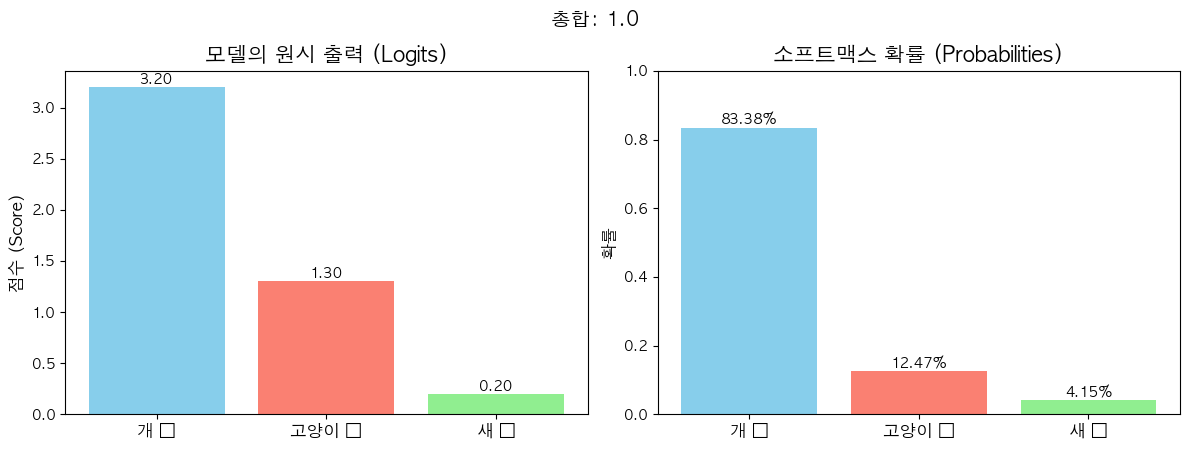

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

# 1. 소프트맥스 함수 정의
def softmax(z):
    """Numpy 배열을 입력받아 소프트맥스 확률을 계산"""
    exp_z = np.exp(z - np.max(z)) # 오버플로우 방지를 위한 안정화 트릭
    return exp_z / exp_z.sum()

# 2. 예시 데이터 (모델의 원시 출력 점수, 로짓)
logits = np.array([3.2, 1.3, 0.2])
class_names = ['개 🐕', '고양이 🐈', '새 🐦']

# 3. 소프트맥스 확률 계산
probabilities = softmax(logits)

# 4. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 그래프 1: 원시 로짓 점수
bars1 = ax1.bar(class_names, logits, color=['skyblue', 'salmon', 'lightgreen'])
ax1.set_title('모델의 원시 출력 (Logits)', fontsize=15)
ax1.set_ylabel('점수 (Score)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
# 막대 위에 값 표시
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center')


# 그래프 2: 소프트맥스 변환 후 확률
bars2 = ax2.bar(class_names, probabilities, color=['skyblue', 'salmon', 'lightgreen'])
ax2.set_title('소프트맥스 확률 (Probabilities)', fontsize=15)
ax2.set_ylabel('확률', fontsize=12)
ax2.tick_params(axis='x', labelsize=12)
ax2.set_ylim(0, 1) # Y축 범위를 0과 1 사이로 고정
# 막대 위에 값 표시
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2%}', va='bottom', ha='center') # % 형태로 표시

# 전체 그래프 제목
fig.suptitle(f'총합: {np.sum(probabilities):.1f}', fontsize=14, y=0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()